# 04 · Ground contact: legs as algebraic springs

How the floor holds ATLAS up: each foot is a penalty spring-damper with friction, worked out fresh every step. This notebook shows the force law, why it is algebraic, and how the parked angle is set.

In [1]:
# Setup: make the repository importable and load the V3 airframe used throughout these notebooks
import sys, math, pathlib
ROOT = pathlib.Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt
from airframe_designer.geometry.airframe import Airframe

np.set_printoptions(precision=4, suppress=True)
plt.rcParams.update({"figure.figsize": (7, 3.6), "axes.grid": True, "grid.alpha": 0.3})

AF_PATH = ROOT / "airframes" / "atlas_v3_v34_foils_50_65_50_tuned.json"
af = Airframe.load(AF_PATH)
af.resolve_mass()
G = 9.80665
print(f"{af.name}: {af.mass.mass:.2f} kg, {len(af.active_rotors())} fans, hover pitch {af.hover_pitch_deg} deg, parked {af.landed_pitch_deg} deg")

ATLAS_V3_V34_FOILS_50_65_50_TUNED: 11.83 kg, 9 fans, hover pitch 23.85 deg, parked 23.85 deg


In [2]:
from airframe_designer.dynamics.rigid_body import RigidBody
from airframe_designer.dynamics.quaternion import q_to_rotmat, q_to_euler
rb = RigidBody(af)
legs = rb.legs
for l in af.active_legs():
    print(f"{l.name:12s} attach {np.round(l.attach, 3)}  foot {np.round(l.foot(), 3)}  k {l.stiffness:.0f} N/m  c {l.damping:.0f} N s/m  mu {l.friction}")
print("static check:", af.leg_static())

L            attach [ 0.086 -0.03  -0.124]  foot [-0.518 -0.621  0.257]  k 1500 N/m  c 80 N s/m  mu 0.8
R            attach [ 0.086  0.03  -0.124]  foot [-0.518  0.621  0.257]  k 1500 N/m  c 80 N s/m  mu 0.8
N (not in CAD) attach [0.36 0.   0.12]  foot [0.36  0.    0.645]  k 1500 N/m  c 80 N s/m  mu 0.8
static check: {'compression_m': 0.025780593222222217, 'zeta': 0.5200949259867795}


## 1. The contact force law

**Theory.** For a foot with penetration $\delta$ into the floor (positive when below $z = 0$) and penetration rate $\dot\delta$:

$$f_n = \max\big(k\,\delta + c\,\max(\dot\delta, 0),\ 0\big),\qquad \mathbf f_t = -\mu\,f_n\,\frac{\mathbf v_h}{\max(\lVert\mathbf v_h\rVert,\ 0.2\ \text{m/s})}.$$

The floor can only push (the max with 0), damping acts only in compression, and friction is Coulomb above 0.2 m/s and viscous below. The moment about the CG is $\mathbf r\times\mathbf f$ for each foot.

> **Note: leg contact is algebraic**
>
> "Algebraic" means the leg force is just a formula of the current state, with no memory. Each step the code works out where each foot is from the position and attitude, checks whether it is below the floor and by how much, and sets the force from that. So the legs behave like massless springs that respond instantly, no compression is stored between steps, and friction has no "stuck" memory (a parked aircraft can creep very slowly instead of sticking). A multibody engine with each leg as its own body would turn the legs into states.

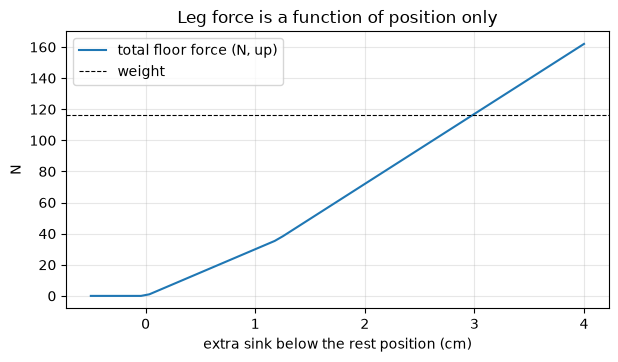

feet in contact across the sweep: [0, 2, 3]


In [3]:
# Push the parked body down step by step and read the algebraic force each time
R = q_to_rotmat(rb.q)
pos0 = rb.pos.copy()
sink = np.linspace(-0.005, 0.04, 60)
fz, feet = [], []
for s in sink:
    F, M, on_ground, n = legs.forces(pos0 + [0, 0, s], np.zeros(3), R, np.zeros(3))
    fz.append(-F[2]); feet.append(n)
plt.plot(sink * 100, fz, label="total floor force (N, up)")
plt.axhline(af.mass.mass * G, color="k", lw=0.8, ls="--", label="weight")
plt.xlabel("extra sink below the rest position (cm)"); plt.ylabel("N"); plt.legend(); plt.title("Leg force is a function of position only"); plt.show()
print("feet in contact across the sweep:", sorted(set(feet)))

> **Note: spring constant, sink and damping**
>
> 11.8 kg on 3 feet means each foot carries about 38.7 N. With this airframe's $k = 1500$ N/m per leg that is about 2.6 cm of static sink, and $c = 80$ N s/m gives a damping ratio of about 0.5 (the `static check` line above). `Airframe.auto_leg_constants` can resize them for a chosen sink and damping ratio (by default 2 cm and 0.8).

## 2. Why the damping is clamped

**Theory.** For a foot at lever arm $\mathbf r$ with contact normal $\mathbf n$, the effective mass the foot "feels" is $m_{\text{eff}} = 1/\big(1/m + (\mathbf r\times\mathbf n)^{\mathsf T} I^{-1}(\mathbf r\times\mathbf n)\big)$. A damper $c$ integrated explicitly over one step is stable only while $c\,\Delta t / m_{\text{eff}}$ stays small, so the code limits the damping force to what can remove at most half of the foot's velocity in one step ($c \le 0.5\,m_{\text{eff}}/\Delta t$).

In [4]:
m_eff = legs.effective_mass(af.mass.mass, np.linalg.inv(af.mass.tensor()), R)
print("effective mass per foot (kg):", np.round(m_eff, 2))
print("damping limit at 1 ms (N s/m):", np.round(0.5 * m_eff / 1e-3, 0), " actual:", [round(l.damping) for l in af.active_legs()])

effective mass per foot (kg): [1.3  1.26 1.87]
damping limit at 1 ms (N s/m): [650. 631. 936.]  actual: [80, 80, 80]


## 3. Setting the parked angle

**Theory.** `Airframe.with_attitude(park_pitch_deg=...)` re-solves the legs under the same hard points so that every foot lies on the floor at the requested pitch, keeping the mean leg length. If that would make a leg shorter than 3 cm (steep nose-down parks), it lowers the floor plane instead so the shortest leg is 3 cm and the others grow. It also checks the stand does not tip (the CG must project inside the feet).

> **Note: why the aircraft rests below the solved angle**
>
> The legs are solved for a geometric angle, but under 11.8 kg each spring compresses about 2 cm, and the front feet compress a little differently from the rear ones. The aircraft therefore settles about 1.85° further nose-down. To rest at −16°, the legs are solved for −14.15°.

In [5]:
for park in (-6.2, -14.15, -15.2):
    a2 = af.with_attitude(park_pitch_deg=park)
    b = RigidBody(a2); b.set_motor_commands(np.zeros(b.rotors.n))
    for _ in range(4000):
        b.step(1e-3, detail=False)
    print(f"legs solved for {park:6.2f} deg -> rests at {math.degrees(q_to_euler(b.q)[1]):6.2f} deg")

legs solved for  -6.20 deg -> rests at  -7.95 deg
legs solved for -14.15 deg -> rests at -16.00 deg
legs solved for -15.20 deg -> rests at -17.07 deg
